In [10]:
# Cài đặt keras-tuner nếu chưa có (dùng cho Colab/Kaggle)
!pip install -q keras-tuner

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import keras_tuner as kt

import os, shutil
import requests
from PIL import Image
from io import BytesIO
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cấu hình thư mục lưu model trên Drive
drive_model_dir = "/content/drive/MyDrive/KHDL_project/"
print("Đã kết nối Drive và tạo thư mục lưu model thành công!")

# Đường dẫn bộ dữ liệu (cập nhật lại nếu dữ liệu của bạn nằm ở chỗ khác)
train_path = "/content/drive/MyDrive/KHDL_project/data/train"
validation_path = "/content/drive/MyDrive/KHDL_project/data/val"
test_path = "/content/drive/MyDrive/KHDL_project/data/test"

image_categories = os.listdir(train_path)
print(f"Số lượng nhãn phân loại: {len(image_categories)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã kết nối Drive và tạo thư mục lưu model thành công!
Số lượng nhãn phân loại: 10


In [19]:
BATCHSIZE = 128
TARGETSIZE = (224, 224)

# Train Generator (Có Augmentation)
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_image_generator = train_gen.flow_from_directory(
    train_path,
    target_size=TARGETSIZE,
    batch_size=BATCHSIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# Validation & Test Generator (Chỉ chuẩn hóa, không Augmentation)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_image_generator = val_gen.flow_from_directory(
    validation_path,
    target_size=TARGETSIZE,
    batch_size=BATCHSIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_image_generator = test_gen.flow_from_directory(
    test_path,
    target_size=TARGETSIZE,
    batch_size=BATCHSIZE,
    class_mode='categorical',
    shuffle=False
)

NUMCLASSES = len(train_image_generator.class_indices)

Found 7000 images belonging to 10 classes.
Found 1475 images belonging to 10 classes.
Found 1500 images belonging to 10 classes.


In [13]:
def build_tuning_model(hp):
    # Khởi tạo backbone MobileNetV2 (đóng băng trọng số)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)

    # Keras Tuner: Tìm số lượng node cho lớp Dense
    hp_units = hp.Int('dense_units', min_value=64, max_value=256, step=64)
    x = Dense(units=hp_units, activation='relu')(x)

    # Keras Tuner: Tìm tỷ lệ Dropout tối ưu
    hp_dropout = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    x = Dropout(rate=hp_dropout)(x)

    outputs = Dense(NUMCLASSES, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)

    # Keras Tuner: Tìm Learning Rate tối ưu
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Thiết lập Hyperband Tuner
tuner_dir = os.path.join(drive_model_dir, "keras_tuner_log")
tuner = kt.Hyperband(
    build_tuning_model,
    objective='val_loss',
    max_epochs=10,
    factor=3,
    directory=tuner_dir,
    project_name='mobilenet_v2_tuning'
)

Reloading Tuner from /content/drive/MyDrive/KHDL_project/keras_tuner_log/mobilenet_v2_tuning/tuner0.json


In [ ]:
print("Bắt đầu dò tìm siêu tham số tốt nhất...")
stop_early_tuner = EarlyStopping(monitor='val_loss', patience=3)

tuner.search(
    train_image_generator,
    epochs=10,
    validation_data=val_image_generator,
    callbacks=[stop_early_tuner],
    verbose=1
)

# Lấy bộ tham số xịn nhất
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n--- BỘ SIÊU THAM SỐ TỐT NHẤT THU ĐƯỢC ---")
print(f" Lớp Dense (Units): {best_hps.get('dense_units')}")
print(f" Tỷ lệ Dropout: {best_hps.get('dropout_rate'):.2f}")
print(f" Tốc độ học (Learning Rate): {best_hps.get('learning_rate')}")

# Khởi tạo mô hình chính thức với bộ tham số vừa tìm được
final_model = tuner.hypermodel.build(best_hps)
final_model.summary()

In [16]:

# 1. Tự động xây dựng lại mô hình với Best Params đã tìm được (Khỏi cần Tuner)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

# Lắp Best Params: Dense 64 và Dropout 0.2
x = Dense(units=64, activation='relu')(x)
x = Dropout(rate=0.2)(x)

NUMCLASSES = len(train_image_generator.class_indices)
outputs = Dense(NUMCLASSES, activation='softmax')(x)
final_model = Model(inputs=inputs, outputs=outputs)

# Lắp Best Params: Learning Rate 0.001
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Đã khởi tạo Model với Best Params thành công!")

# 2. Cấu hình đường dẫn lưu Model
drive_model_dir = "/content/drive/MyDrive/KHDL_project/"
best_model_path = os.path.join(drive_model_dir, "best_mobilenetv2_model_2.keras")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    best_model_path,
    save_best_only=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

# 3. Bắt đầu huấn luyện chính thức
print("Bắt đầu huấn luyện mô hình chính thức...")
history = final_model.fit(
    train_image_generator,
    epochs=100,
    validation_data=val_image_generator,
    callbacks=[checkpoint, early_stopping]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Đã khởi tạo Model với Best Params thành công!
Bắt đầu huấn luyện mô hình chính thức...
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 54s/step - accuracy: 0.7055 - loss: 1.0017 
Epoch 1: val_loss improved from None to 0.07512, saving model to /content/drive/MyDrive/KHDL_project/best_mobilenetv2_model_2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/KHDL_project/best_mobilenetv2_model_2.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 3679s 67s/step - accuracy: 0.8699 - loss: 0.4718 - val_accuracy: 0.9817 - val_loss: 0.0751
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9728 - loss: 0.1015
Epoch 2: val_loss improved from 0.07512 to 0.06461, saving model to /content/drive/MyDrive/KHDL_project/best_mobilenetv2_model_2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/KHDL_project/best_mobilenetv2_model_2.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9760 - loss: 0.0876 - val_accuracy: 0.9803 - val_lo

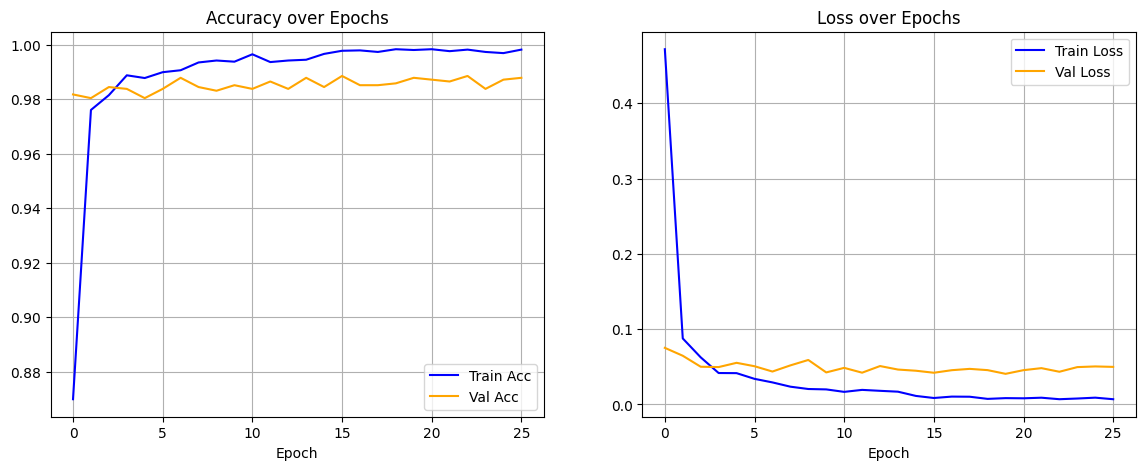

In [17]:
plt.figure(figsize=(14, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.show()

In [21]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TARGETSIZE = (224, 224)
BATCHSIZE = 128
test_path = "/content/drive/MyDrive/KHDL_project/data/test"

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_image_generator = test_gen.flow_from_directory(
    test_path,
    target_size=TARGETSIZE,
    batch_size=BATCHSIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1500 images belonging to 10 classes.


Đang quét và lọc bỏ file lỗi trong tập Test thực tế...
⚠️ Đã phát hiện và bỏ qua file lỗi: /content/drive/MyDrive/KHDL_project/data/test/asparagus/asparagus1522.jpg

 Đã xử lý xong! Tổng số ảnh hợp lệ đưa vào test: 1499
Mô hình đang dự đoán tập Test...
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step

 Độ chính xác (Accuracy) trên tập Test: 98.73%

Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

   asparagus       1.00      1.00      1.00       149
      banana       0.99      0.99      0.99       150
    broccoli       0.99      0.99      0.99       150
      carrot       0.99      0.99      0.99       150
        corn       1.00      0.99      1.00       150
    eggplant       0.94      0.97      0.96       150
      orange       0.99      0.99      0.99       150
   pineapple       0.99      0.99      0.99       150
      potato       0.99      0.98      0.98       150
      tomato       0.99      0.98      0.99       150

    accuracy        

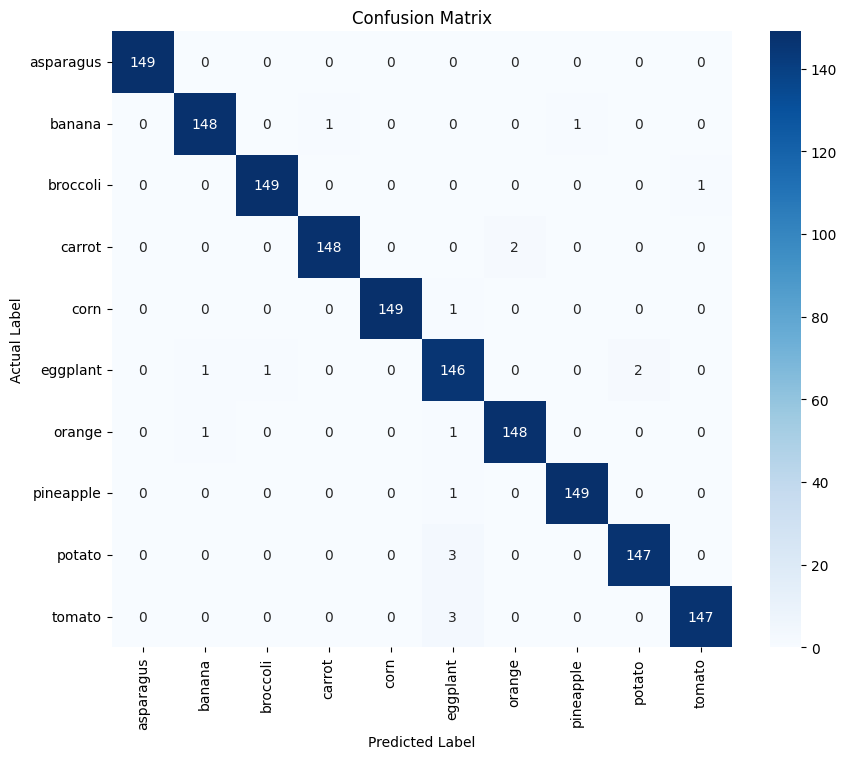

In [23]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tải mô hình
best_model_path = "/content/drive/MyDrive/KHDL_project/best_mobilenetv2_model_2.keras"
loaded_best_model = load_model(best_model_path)

# 2. Định nghĩa đường dẫn và lấy danh sách nhãn (class) chuẩn từ generator cũ
test_path = "/content/drive/MyDrive/KHDL_project/data/test"
class_labels = sorted(os.listdir(test_path))
class_to_idx = {cls: idx for idx, cls in enumerate(class_labels)}

y_true = []
y_pred = []
compiled_features = []

print("Đang quét và lọc bỏ file lỗi trong tập Test thực tế...")

# 3. Duyệt thủ công qua từng file ảnh để loại bỏ file rác
for folder_name in class_labels:
    folder_path = os.path.join(test_path, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            # Thử load ảnh bằng Keras/PIL xem có lỗi không
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_preprocessed = preprocess_input(img_array)

            compiled_features.append(img_preprocessed)
            y_true.append(class_to_idx[folder_name])

        except Exception as e:
            # Phát hiện file lỗi -> Bỏ qua và in ra màn hình để bạn biết
            print(f"⚠️ Đã phát hiện và bỏ qua file lỗi: {img_path}")
            continue

# Chuyển đổi thành numpy array để predict
X_test = np.array(compiled_features)
y_true = np.array(y_true)

print(f"\n Đã xử lý xong! Tổng số ảnh hợp lệ đưa vào test: {len(X_test)}")

# 4. Thực hiện dự đoán trên danh sách ảnh sạch
print("Mô hình đang dự đoán tập Test...")
y_pred_probs = loaded_best_model.predict(X_test, batch_size=128)
y_pred = np.argmax(y_pred_probs, axis=1)

# 5. Xuất báo cáo kết quả
accuracy_all = np.sum(y_pred == y_true) / len(y_true) * 100
print(f"\n Độ chính xác (Accuracy) trên tập Test: {accuracy_all:.2f}%\n")

print("Báo cáo phân loại (Classification Report):")
print(classification_report(y_true, y_pred, target_names=class_labels))

# 6. Vẽ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

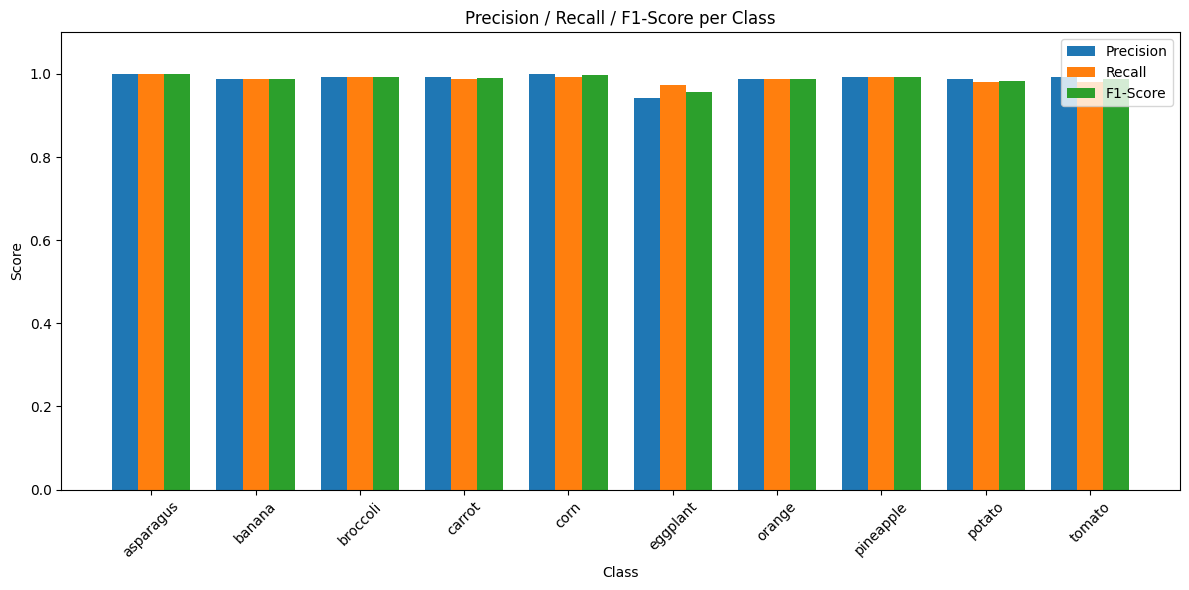

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

x = range(len(class_labels))

plt.figure(figsize=(12, 6))
plt.bar(x, precision, width=0.25, label='Precision')
plt.bar([p + 0.25 for p in x], recall, width=0.25, label='Recall')
plt.bar([p + 0.50 for p in x], f1, width=0.25, label='F1-Score')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Precision / Recall / F1-Score per Class')
plt.xticks([p + 0.25 for p in x], class_labels, rotation=45)
plt.ylim([0, 1.1])
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
print(train_image_generator.class_indices)

{'asparagus': 0, 'banana': 1, 'broccoli': 2, 'carrot': 3, 'corn': 4, 'eggplant': 5, 'orange': 6, 'pineapple': 7, 'potato': 8, 'tomato': 9}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


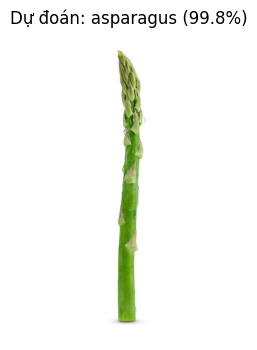

Lỗi khi xử lý URL https://nutritionsource.hsph.harvard.edu/wp-content/uploads/2018/08/bananas-1354785_1920.jpg: cannot identify image file <_io.BytesIO object at 0x787586229e90>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


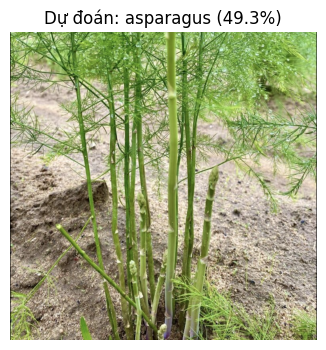

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


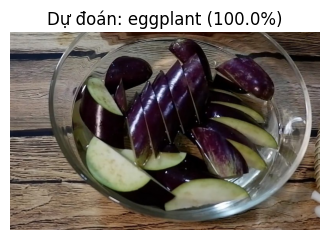

In [30]:
def load_image_from_url_mobilenet(url, target_size=TARGETSIZE):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img_resized = img.resize(target_size)
    img_array = np.array(img_resized)

    # Chuẩn hóa đầu vào theo MobileNetV2
    img_preprocessed = preprocess_input(img_array)
    img_tensor = np.expand_dims(img_preprocessed, axis=0)
    return img, img_tensor

def predict_images_mobilenet(model, image_urls, class_indices, target_size=TARGETSIZE):
    inv_class_indices = {v: k for k, v in class_indices.items()}

    for url in image_urls:
        try:
            img, img_data = load_image_from_url_mobilenet(url, target_size)
            pred_probs = model.predict(img_data)
            pred_class = np.argmax(pred_probs, axis=1)[0]
            predicted_label = inv_class_indices[pred_class]
            confidence = np.max(pred_probs) * 100

            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'Dự đoán: {predicted_label} ({confidence:.1f}%)')
            plt.show()

        except Exception as e:
            print(f"Lỗi khi xử lý URL {url}: {e}")

# Chạy thử với một vài link ảnh thực tế
test_urls = [
    "https://media.istockphoto.com/id/1404417756/photo/single-stem-of-green-asparagus-isolated-with-clipping-path.jpg?s=612x612&w=0&k=20&c=po9AsZxHEvXIVk8ea5g37fUoJq0X0Bg2omvRHd1_138=",
    "https://nutritionsource.hsph.harvard.edu/wp-content/uploads/2018/08/bananas-1354785_1920.jpg",
    "https://bizweb.dktcdn.net/100/464/861/articles/hi-nh-a-nh.png?v=1741419926660",
    "https://bizweb.dktcdn.net/100/489/006/files/canh-ca-tim-2.jpg?v=1702185385253"
]

predict_images_mobilenet(loaded_best_model, test_urls, train_image_generator.class_indices)